In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('C:\\Users\\Rajdeep\\Downloads\\student_placement_salary_elite_v2.csv')

# Initial look at the data
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   str    
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   str    
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   int64  
 16 

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


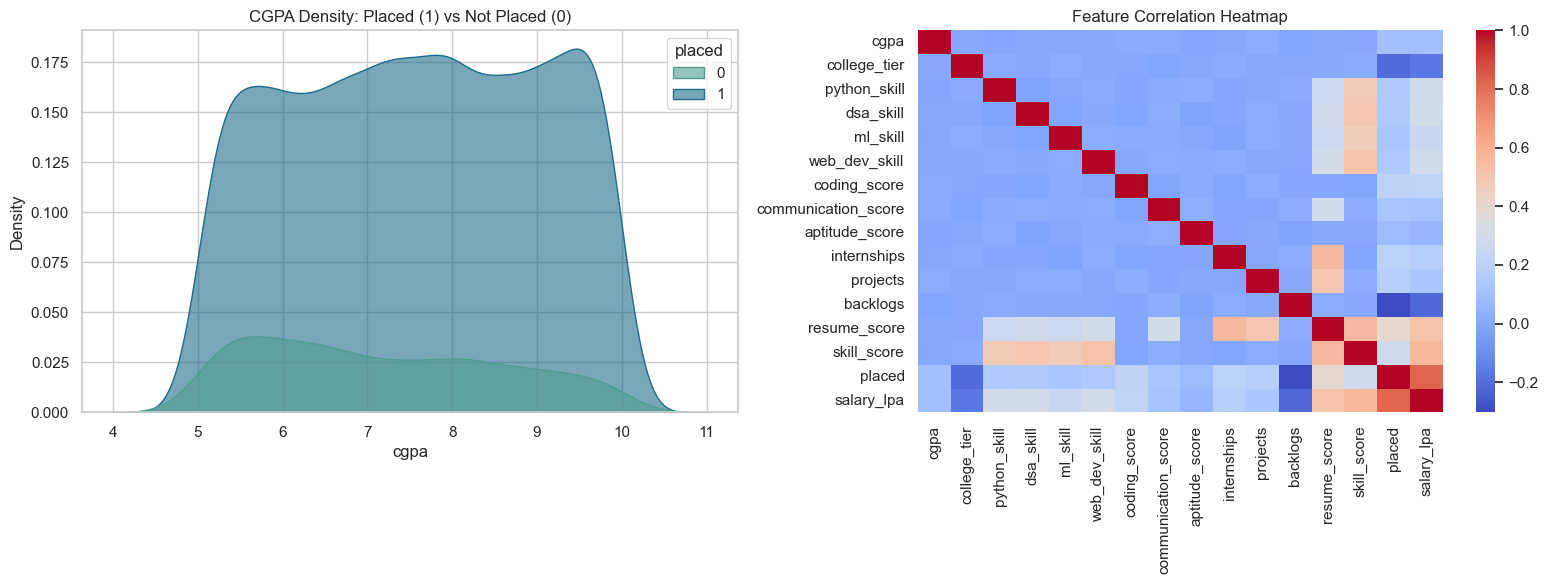

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Subplot 1: KDE Plot (Density of CGPA by Placement)
# This shows if there is a clear "threshold" CGPA for getting placed.
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='cgpa', hue='placed', fill=True, palette='crest', alpha=0.6)
plt.title('CGPA Density: Placed (1) vs Not Placed (0)')

# Subplot 2: Heatmap of Correlations
# This visualizes how different student attributes relate to one another.
plt.subplot(1, 2, 2)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [42]:
# Initialize the three classification methods
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True)
}

results = []

# Loop through models and test performance
for name, model in models.items():
    # Use scaled data for LR and SVM; raw data for Random Forest
    X_tr = X_train_scaled if name != "Random Forest" else X_train
    X_ts = X_test_scaled if name != "Random Forest" else X_test
    
    model.fit(X_tr, y_train)
    preds = model.predict(X_ts)
    acc = accuracy_score(y_test, preds)
    
    results.append({"Model": name, "Accuracy": acc})
    print(f"Finished training {name}...")

# Create results dataframe
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

Finished training Logistic Regression...
Finished training Random Forest...
Finished training SVM...


In [43]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

Logistic Regression Accuracy: 0.9233


In [44]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Trees don't strictly require scaling
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.9061


In [45]:
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_acc:.4f}")

SVM Accuracy: 0.9183


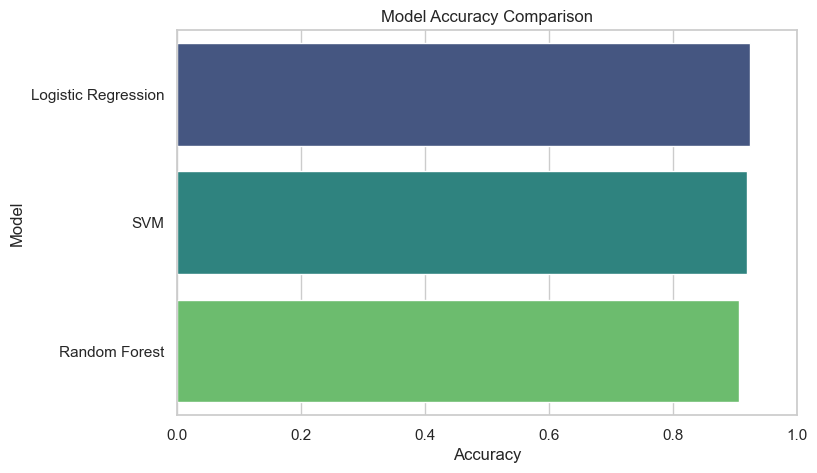

Comparison Table:
                 Model  Accuracy
0  Logistic Regression  0.923333
2                  SVM  0.918333
1        Random Forest  0.906111


In [46]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [lr_acc, rf_acc, svm_acc]
})

# Sort by accuracy
results = results.sort_values(by='Accuracy', ascending=False)

# Updated barplot to satisfy new Seaborn requirements
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Accuracy', 
    y='Model', 
    data=results, 
    hue='Model',     # Assign 'Model' to hue for coloring
    palette='viridis', 
    legend=False     # Hide the legend since the y-axis already labels the models
)
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1.0)
plt.show()

print("Comparison Table:")
print(results)

In [47]:
best_model_name = results.iloc[0]['Model']
best_accuracy = results.iloc[0]['Accuracy']

print(f"--- FINAL VERDICT ---")
print(f"The best model for predicting student placement is: {best_model_name}")
print(f"Achieved Test Accuracy: {best_accuracy:.2%}")

--- FINAL VERDICT ---
The best model for predicting student placement is: Logistic Regression
Achieved Test Accuracy: 92.33%
